In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-06-05 20:53:38.650960: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-05 20:53:38.654561: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-05 20:53:38.666960: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749171218.688624     157 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749171218.695164     157 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-05 20:53:38.724127: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from hyperion_utils import *
from sklearn.decomposition import PCA

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
myTreatmentColumn = 'groupe'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'CPC12', 
                                                                         aTreatmentColumn = myTreatmentColumn,     
                                                                         aSkipTemp = False) 

In [5]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [6]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    # myCovariates = getCovariatePreprocessor(['bin__' + myTreatmentColumn])
    # myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [7]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [8]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(64, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


2025-06-05 20:53:45.031618: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8234 - loss: 0.4472 - roc_auc: 0.4471 - val_accuracy: 0.9200 - val_loss: 0.2773 - val_roc_auc: 0.6169
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9283 - loss: 0.2519 - roc_auc: 0.6441 - val_accuracy: 0.9200 - val_loss: 0.2813 - val_roc_auc: 0.6768
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9313 - loss: 0.2026 - roc_auc: 0.8455 - val_accuracy: 0.9200 - val_loss: 0.2647 - val_roc_auc: 0.7238
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9318 - loss: 0.2131 - roc_auc: 0.7883 - val_accuracy: 0.9200 - val_loss: 0.2489 - val_roc_auc: 0.7493
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9406 - loss: 0.1787 - roc_auc: 0.8716 - val_accuracy: 0.9257 - val_loss: 0.2434 - val_roc_auc: 0.7595
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9258 - loss: 0.1981 - roc_auc: 0.8981 - val_accuracy: 0.9257 - val_loss: 0.2379 - val_roc_auc: 0.780

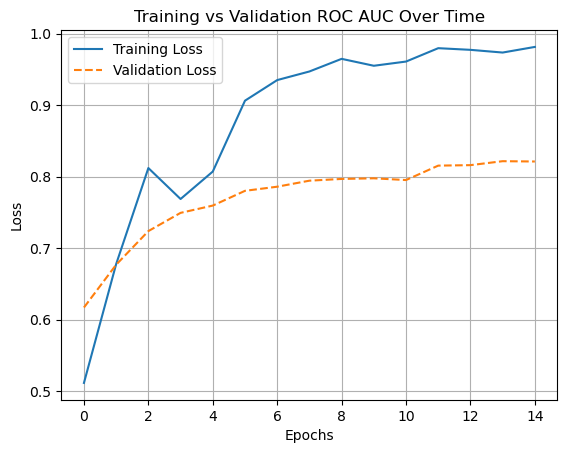

In [10]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ROC AUC Score: 0.8194


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 7s 917us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 6s 830us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 6s 814us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 6s 801us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 6s 827us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 8s 984us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 7s 966us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
7663/7663 ━━━━━━━━━━━━━━━━━━━━ 7s 911us/step


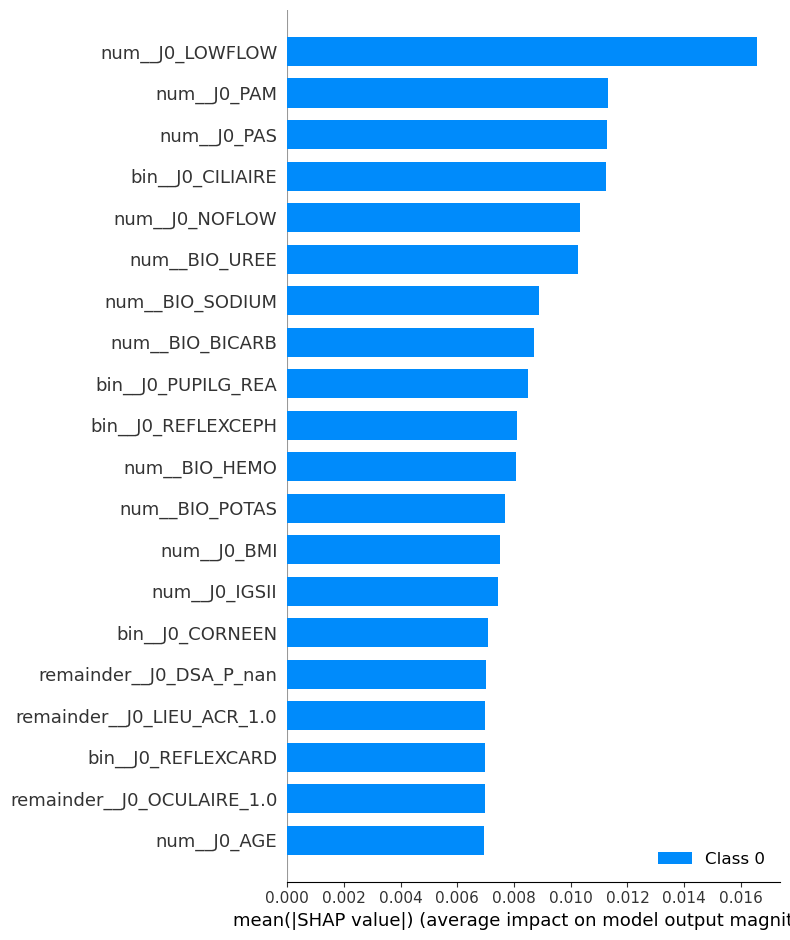

In [12]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [14]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "bin__groupe"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'bin__groupe' is ranked #171 out of 222 in importance with mean(|SHAP|) = 0.0002


In [16]:
y_pred_probs.T[0, :]

array([1.13434039e-01, 2.78856052e-04, 1.68566387e-02, 8.65397800e-04,
       3.89784644e-03, 6.17709290e-03, 8.61611962e-02, 3.26378495e-02,
       1.25186592e-01, 2.88149059e-01, 9.29038739e-04, 1.19703659e-03,
       8.47152807e-03, 2.77577378e-02, 6.12306921e-03, 2.22417247e-03,
       1.84005557e-03, 1.36765768e-04, 4.25638855e-02, 3.52215581e-02,
       1.87280595e-01, 4.81105223e-02, 3.48059721e-02, 2.59975381e-02,
       1.35487484e-04, 2.58279052e-02, 4.76200774e-04, 4.80452925e-02,
       1.49062136e-03, 3.46969930e-03, 7.21949246e-03, 1.97706804e-01,
       1.13088991e-02, 4.45527345e-04, 6.44543990e-02, 1.30159169e-01,
       4.94116079e-03, 1.93661377e-02, 4.07735854e-02, 4.94533498e-03,
       4.21050191e-02, 7.04219332e-03, 5.47189964e-03, 1.10588409e-02,
       4.12089795e-01, 2.53549784e-01, 1.11381186e-03, 3.14481318e-01,
       8.63598194e-03, 4.28301375e-03, 1.02805470e-05, 2.28468068e-02,
       1.71750113e-02, 2.21768185e-03, 4.61331016e-04, 1.84003811e-03,
      

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Optimization terminated successfully.
         Current function value: 0.266554
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263996
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 2.076808932228545
p-value: 0.1495525406108744
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  406
Model:                          Logit   Df Residuals:                      403
Method:                           MLE   Df Model:                            2
Date:                Thu, 05 Jun 2025   Pseudo R-squ.:                 0.01194
Time:                        20:25:31   Log-Likelihood:                -108.22
converged:                       True   LL-Null:                       -109.53
Covariance Type:      

0.1495525406108744

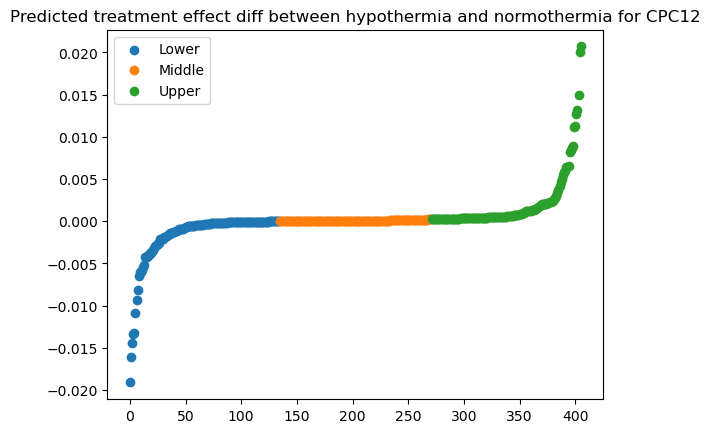

In [17]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'CPC12', aGroup = 'bin__groupe', aUseNeuralNetwork = True, aByGroup = False)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Optimization terminated successfully.
         Current function value: 0.274583
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.274260
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.11278136073011069
p-value: 0.7369995467194708
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  175
Model:                          Logit   Df Residuals:                      172
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.01502
Time:                        17:39:34   Log-Likelihood:                -48.052
converged:                       True   LL-Null:                       -48.785
Covariance Type:        

0.7369995467194708

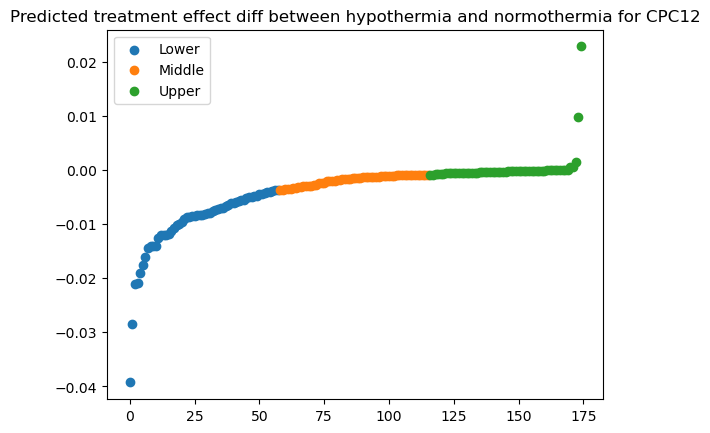

In [16]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'CPC12', aGroup = 'bin__groupe', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined